#### **Assignment-01: SMS Spam Classification**
#### **Nisith Ranjan Hazra (MDS202427)**
#### **Model Training**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

#### **Load the train, test and validation spolit**

In [2]:

training_dataset = pd.read_csv('dataset/train_data.csv')
validation_dataset = pd.read_csv('dataset/validation_data.csv')
testing_dataset = pd.read_csv('dataset/test_data.csv')
print(f"Training Samples: {len(training_dataset)}, "
      f"Validation Samples: {len(validation_dataset)}, "
      f"Testing Samples: {len(testing_dataset)}")


Training Samples: 4457, Validation Samples: 557, Testing Samples: 558


In [3]:
#### Separate input features and target labels

X_train_text = training_dataset['message']
y_train_target = (training_dataset['label'] == 'spam').astype(int)

X_val_text = validation_dataset['message']
y_val_target = (validation_dataset['label'] == 'spam').astype(int)

X_test_text = testing_dataset['message']
y_test_target = (testing_dataset['label'] == 'spam').astype(int)

print(f"Training Samples: {len(X_train_text)}, "
      f"Spam Instances: {y_train_target.sum()}")


Training Samples: 4457, Spam Instances: 598


#### **Feature Extraction - TF-IDF**

In [4]:
#### Initialize TF-IDF feature extractor
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_features = tfidf_vectorizer.fit_transform(X_train_text)
X_val_features = tfidf_vectorizer.transform(X_val_text)
X_test_features = tfidf_vectorizer.transform(X_test_text)

print(f"Number of TF-IDF Features: {X_train_features.shape[1]}")
print(f"Training Feature Matrix Shape: {X_train_features.shape}")


Number of TF-IDF Features: 5000
Training Feature Matrix Shape: (4457, 5000)


In [5]:
#### Save the vectorizer code 
import joblib 
import os
joblib.dump(
    tfidf_vectorizer,
    os.path.join("SAVED_MODELS", "tfidf_vectorizer.pkl")
)
print("TF-IDF Vectorizer saved successfully.")

TF-IDF Vectorizer saved successfully.


#### **Model 1: Rule-based Baseline**

Simple keyword matching - if message contains spam keywords, classify as spam.

In [6]:
### Rule-based spam detection using keyword heuristics (derived from EDA insights)

spam_keyword_list = [
    'free', 'win', 'winner', 'cash', 'prize', 'claim', 'urgent',
    'call', 'txt', 'text', 'mobile', 'reply', 'stop', 'www',
    'click', 'subscribe', 'ringtone', 'nokia', 'award', 'congratulations'
]

def heuristic_spam_classifier(text_series):
    predicted_labels = []
    
    for text in text_series:
        normalized_text = text.lower()
        
        # Count occurrences of predefined spam-indicative keywords
        matched_keyword_count = sum(
            1 for token in spam_keyword_list if token in normalized_text
        )
        
        # Apply rule: classify as spam if at least 2 keywords are present
        if matched_keyword_count >= 2:
            predicted_labels.append(1)
        else:
            predicted_labels.append(0)
    
    return np.array(predicted_labels)


In [7]:
#### Evaluate heuristic-based spam classifier on training and validation sets

train_rule_predictions = heuristic_spam_classifier(X_train_text)
val_rule_predictions = heuristic_spam_classifier(X_val_text)

print("Heuristic Rule-Based Model Results:")

print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train_target, train_rule_predictions):.4f}")
print(f"  Precision: {precision_score(y_train_target, train_rule_predictions):.4f}")
print(f"  Recall: {recall_score(y_train_target, train_rule_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_train_target, train_rule_predictions):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val_target, val_rule_predictions):.4f}")
print(f"  Precision: {precision_score(y_val_target, val_rule_predictions):.4f}")
print(f"  Recall: {recall_score(y_val_target, val_rule_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_val_target, val_rule_predictions):.4f}")


Heuristic Rule-Based Model Results:

Training Set:
  Accuracy: 0.9536
  Precision: 0.9014
  Recall: 0.7341
  F1-Score: 0.8092

Validation Set:
  Accuracy: 0.9533
  Precision: 0.8871
  Recall: 0.7432
  F1-Score: 0.8088


In [8]:
### Confusion matrix evaluation for heuristic-based classifier

print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val_target, val_rule_predictions))

print("\nClassification Report:")
print(classification_report(
    y_val_target,
    val_rule_predictions,
    target_names=['ham', 'spam']
))


Confusion Matrix (Validation Set):
[[476   7]
 [ 19  55]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.99      0.97       483
        spam       0.89      0.74      0.81        74

    accuracy                           0.95       557
   macro avg       0.92      0.86      0.89       557
weighted avg       0.95      0.95      0.95       557



#### **Model 2: TF-IDF and  Logistic Regression**

In [9]:
### Train Logistic Regression classifier

logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression_model.fit(X_train_features, y_train_target)

### Generate predictions
train_lr_predictions = logistic_regression_model.predict(X_train_features)
val_lr_predictions = logistic_regression_model.predict(X_val_features)

### Generate probability scores
train_lr_probabilities = logistic_regression_model.predict_proba(X_train_features)[:, 1]
val_lr_probabilities = logistic_regression_model.predict_proba(X_val_features)[:, 1]

print("Logistic Regression Model Performance:")

print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train_target, train_lr_predictions):.4f}")
print(f"  Precision: {precision_score(y_train_target, train_lr_predictions):.4f}")
print(f"  Recall: {recall_score(y_train_target, train_lr_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_train_target, train_lr_predictions):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val_target, val_lr_predictions):.4f}")
print(f"  Precision: {precision_score(y_val_target, val_lr_predictions):.4f}")
print(f"  Recall: {recall_score(y_val_target, val_lr_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_val_target, val_lr_predictions):.4f}")


Logistic Regression Model Performance:

Training Set:
  Accuracy: 0.9715
  Precision: 0.9896
  Recall: 0.7960
  F1-Score: 0.8823

Validation Set:
  Accuracy: 0.9641
  Precision: 1.0000
  Recall: 0.7297
  F1-Score: 0.8438


In [10]:
# Confusion Matrix and Classification Report for Logistic Regression (Validation Set)

print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val_target, val_lr_predictions))

print("\nClassification Report:")
print(classification_report(
    y_val_target,
    val_lr_predictions,
    target_names=['ham', 'spam']
))


Confusion Matrix (Validation Set):
[[483   0]
 [ 20  54]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       483
        spam       1.00      0.73      0.84        74

    accuracy                           0.96       557
   macro avg       0.98      0.86      0.91       557
weighted avg       0.97      0.96      0.96       557



### Model 3: TF-IDF + Naive Bayes

In [11]:
# Train Multinomial Naive Bayes classifier

naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_features, y_train_target)

# Generate predictions
train_nb_predictions = naive_bayes_model.predict(X_train_features)
val_nb_predictions = naive_bayes_model.predict(X_val_features)

# Generate probability scores
train_nb_probabilities = naive_bayes_model.predict_proba(X_train_features)[:, 1]
val_nb_probabilities = naive_bayes_model.predict_proba(X_val_features)[:, 1]

print("Multinomial Naive Bayes Model Performance:")

print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train_target, train_nb_predictions):.4f}")
print(f"  Precision: {precision_score(y_train_target, train_nb_predictions):.4f}")
print(f"  Recall: {recall_score(y_train_target, train_nb_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_train_target, train_nb_predictions):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val_target, val_nb_predictions):.4f}")
print(f"  Precision: {precision_score(y_val_target, val_nb_predictions):.4f}")
print(f"  Recall: {recall_score(y_val_target, val_nb_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_val_target, val_nb_predictions):.4f}")


Multinomial Naive Bayes Model Performance:

Training Set:
  Accuracy: 0.9859
  Precision: 1.0000
  Recall: 0.8946
  F1-Score: 0.9444

Validation Set:
  Accuracy: 0.9695
  Precision: 1.0000
  Recall: 0.7703
  F1-Score: 0.8702


In [12]:
# Confusion Matrix and Classification Report for Multinomial Naive Bayes (Validation Set)
print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val_target, val_nb_predictions))
print("\nClassification Report:")
print(classification_report(
    y_val_target,
    val_nb_predictions,
    target_names=['ham', 'spam']
))


Confusion Matrix (Validation Set):
[[483   0]
 [ 17  57]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       483
        spam       1.00      0.77      0.87        74

    accuracy                           0.97       557
   macro avg       0.98      0.89      0.93       557
weighted avg       0.97      0.97      0.97       557



### Model 4: TF-IDF + SVM (Support Vector Machine)

In [13]:
# Train Linear Support Vector Machine classifier

svm_classifier_model = LinearSVC(random_state=42, max_iter=2000)
svm_classifier_model.fit(X_train_features, y_train_target)

# Generate predictions
train_svm_predictions = svm_classifier_model.predict(X_train_features)
val_svm_predictions = svm_classifier_model.predict(X_val_features)

# Generate decision scores (used instead of probabilities in LinearSVC)
train_svm_decision_scores = svm_classifier_model.decision_function(X_train_features)
val_svm_decision_scores = svm_classifier_model.decision_function(X_val_features)

print("Linear SVM Model Performance:")

print("\nTraining Set:")
print(f"  Accuracy: {accuracy_score(y_train_target, train_svm_predictions):.4f}")
print(f"  Precision: {precision_score(y_train_target, train_svm_predictions):.4f}")
print(f"  Recall: {precision_score(y_train_target, train_svm_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_train_target, train_svm_predictions):.4f}")

print("\nValidation Set:")
print(f"  Accuracy: {accuracy_score(y_val_target, val_svm_predictions):.4f}")
print(f"  Precision: {precision_score(y_val_target, val_svm_predictions):.4f}")
print(f"  Recall: {recall_score(y_val_target, val_svm_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_val_target, val_svm_predictions):.4f}")


Linear SVM Model Performance:

Training Set:
  Accuracy: 0.9996
  Precision: 0.9983
  Recall: 0.9983
  F1-Score: 0.9983

Validation Set:
  Accuracy: 0.9803
  Precision: 1.0000
  Recall: 0.8514
  F1-Score: 0.9197


In [14]:
# Confusion Matrix and Classification Report for Linear SVM (Validation Set)

print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val_target, val_svm_predictions))

print("\nClassification Report:")
print(classification_report(
    y_val_target,
    val_svm_predictions,
    target_names=['ham', 'spam']
))


Confusion Matrix (Validation Set):
[[483   0]
 [ 11  63]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       483
        spam       1.00      0.85      0.92        74

    accuracy                           0.98       557
   macro avg       0.99      0.93      0.95       557
weighted avg       0.98      0.98      0.98       557



### Hyperparameter Tuning

Fine-tuning the models using GridSearchCV on training data with cross-validation.

In [15]:
# Hyperparameter tuning for Logistic Regression using Grid Search

logistic_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

logistic_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=logistic_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

logistic_grid_search.fit(X_train_features, y_train_target)

print("Logistic Regression - Optimal Hyperparameters:",
      logistic_grid_search.best_params_)

print(f"Best Cross-Validation F1-Score: "
      f"{logistic_grid_search.best_score_:.4f}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increas

Logistic Regression - Optimal Hyperparameters: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation F1-Score: 0.9399


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [16]:
# Hyperparameter tuning for Multinomial Naive Bayes using Grid Search

naive_bayes_param_grid = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'fit_prior': [True, False]
}

naive_bayes_grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid=naive_bayes_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

naive_bayes_grid_search.fit(X_train_features, y_train_target)

print("Multinomial Naive Bayes - Optimal Hyperparameters:",
      naive_bayes_grid_search.best_params_)

print(f"Best Cross-Validation F1-Score: "
      f"{naive_bayes_grid_search.best_score_:.4f}")


Multinomial Naive Bayes - Optimal Hyperparameters: {'alpha': 0.1, 'fit_prior': True}
Best Cross-Validation F1-Score: 0.9452


In [17]:
# Hyperparameter tuning for Linear SVM using Grid Search

svm_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced']
}

svm_grid_search = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid_search.fit(X_train_features, y_train_target)

print("Linear SVM - Optimal Hyperparameters:",
      svm_grid_search.best_params_)

print(f"Best Cross-Validation F1-Score: "
      f"{svm_grid_search.best_score_:.4f}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM - Optimal Hyperparameters: {'C': 5, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
Best Cross-Validation F1-Score: 0.9384


In [18]:
# Summary of tuned models

print("Hyperparameter Optimization Summary:")

print(f"\nLogistic Regression: {logistic_grid_search.best_params_}")
print(f"  Best Cross-Validation F1-Score: {logistic_grid_search.best_score_:.4f}")

print(f"\nMultinomial Naive Bayes: {naive_bayes_grid_search.best_params_}")
print(f"  Best Cross-Validation F1-Score: {naive_bayes_grid_search.best_score_:.4f}")

print(f"\nLinear SVM: {svm_grid_search.best_params_}")
print(f"  Best Cross-Validation F1-Score: {svm_grid_search.best_score_:.4f}")


Hyperparameter Optimization Summary:

Logistic Regression: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
  Best Cross-Validation F1-Score: 0.9399

Multinomial Naive Bayes: {'alpha': 0.1, 'fit_prior': True}
  Best Cross-Validation F1-Score: 0.9452

Linear SVM: {'C': 5, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
  Best Cross-Validation F1-Score: 0.9384


### Benchmark: Score Tuned Models on Test Data

Evaluating all three tuned benchmark models on the held-out test set to select the best one.

In [19]:
# Retrieve best estimators from Grid Search

logistic_best_model = logistic_grid_search.best_estimator_
naive_bayes_best_model = naive_bayes_grid_search.best_estimator_
svm_best_model = svm_grid_search.best_estimator_

# Generate predictions on test dataset
test_lr_predictions = logistic_best_model.predict(X_test_features)
test_nb_predictions = naive_bayes_best_model.predict(X_test_features)
test_svm_predictions = svm_best_model.predict(X_test_features)

# Evaluate all tuned models on test data
model_registry = ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM']
test_prediction_list = [test_lr_predictions, test_nb_predictions, test_svm_predictions]

evaluation_results = []

for model_name, predicted_labels in zip(model_registry, test_prediction_list):
    conf_matrix = confusion_matrix(y_test_target, predicted_labels)
    
    evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_target, predicted_labels),
        'Precision': precision_score(y_test_target, predicted_labels),
        'Recall': recall_score(y_test_target, predicted_labels),
        'F1-Score': f1_score(y_test_target, predicted_labels),
        'False Positives': conf_matrix[0, 1],
        'False Negatives': conf_matrix[1, 0]
    })

evaluation_summary_df = pd.DataFrame(evaluation_results)

print("Final Model Performance on Test Dataset:")
evaluation_summary_df


Final Model Performance on Test Dataset:


,Model,Accuracy,Precision,Recall,F1-Score,False Positives,False Negatives
0,Logistic Regression,0.978495,0.931507,0.906667,0.918919,5,7
1,Multinomial Naive Bayes,0.989247,0.972603,0.946667,0.959459,2,4
2,Linear SVM,0.982079,0.957746,0.906667,0.931507,3,7


In [20]:
# Select best performing model based on F1-Score

best_model_index = evaluation_summary_df['F1-Score'].idxmax()

optimal_model_name = evaluation_summary_df.loc[best_model_index, 'Model']
optimal_f1_score = evaluation_summary_df.loc[best_model_index, 'F1-Score']

print(f"\nBest Performing Model: {optimal_model_name}")
print(f"Test F1-Score: {optimal_f1_score:.4f}")
print(f"Test Precision: {evaluation_summary_df.loc[best_model_index, 'Precision']:.4f}")
print(f"Test Recall: {evaluation_summary_df.loc[best_model_index, 'Recall']:.4f}")
print(f"False Positives: {evaluation_summary_df.loc[best_model_index, 'False Positives']}")
print(f"False Negatives: {evaluation_summary_df.loc[best_model_index, 'False Negatives']}")



Best Performing Model: Multinomial Naive Bayes
Test F1-Score: 0.9595
Test Precision: 0.9726
Test Recall: 0.9467
False Positives: 2
False Negatives: 4


#### **Save Each best tuned model**

In [21]:
import os 
import joblib
model_folder="SAVED_MODELS"
os.makedirs(model_folder, exist_ok=True)

In [22]:
##### Save the logistic regression model 
joblib.dump(
    logistic_grid_search.best_estimator_,
    os.path.join(model_folder, "logistic_regression_best_model.pkl")
)
print("Best Logistic Regression model saved successfully.")

Best Logistic Regression model saved successfully.


In [23]:
#### Save the Multinomial Naive Bayes model
joblib.dump(
    naive_bayes_grid_search.best_estimator_,
    os.path.join(model_folder, "multinomial_naive_bayes_best_model.pkl")
)
print("Best Multinomial Naive Bayes model saved successfully.")

Best Multinomial Naive Bayes model saved successfully.


In [24]:
#### Save the SVM model 
joblib.dump(
    svm_grid_search.best_estimator_,
    os.path.join(model_folder, "linear_svm_best_model.pkl")
)
print("Best Linear SVM model saved successfully.")

Best Linear SVM model saved successfully.


#### **Lets save the overall besat model**

In [25]:
models={
    "Logistic Regression":logistic_grid_search.best_estimator_,
    "Multinomial Naive Bayes":naive_bayes_grid_search.best_estimator_,
    "Linear SVM":svm_grid_search.best_estimator_
}

scores={
    "Logistic Regression":logistic_grid_search.best_score_,
    "Multinomial Naive Bayes":naive_bayes_grid_search.best_score_,
    "Linear SVM":svm_grid_search.best_score_
}

# Select best model
best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

print(f"Best Model: {best_model_name} with F1-Score: {scores[best_model_name]:.4f}")

# Save model
joblib.dump(
    best_model,
    os.path.join(model_folder, "best_spam_classifier_model.pkl")
)

print(f"Best model '{best_model_name}' saved successfully for deployment.")

Best Model: Multinomial Naive Bayes with F1-Score: 0.9452
Best model 'Multinomial Naive Bayes' saved successfully for deployment.


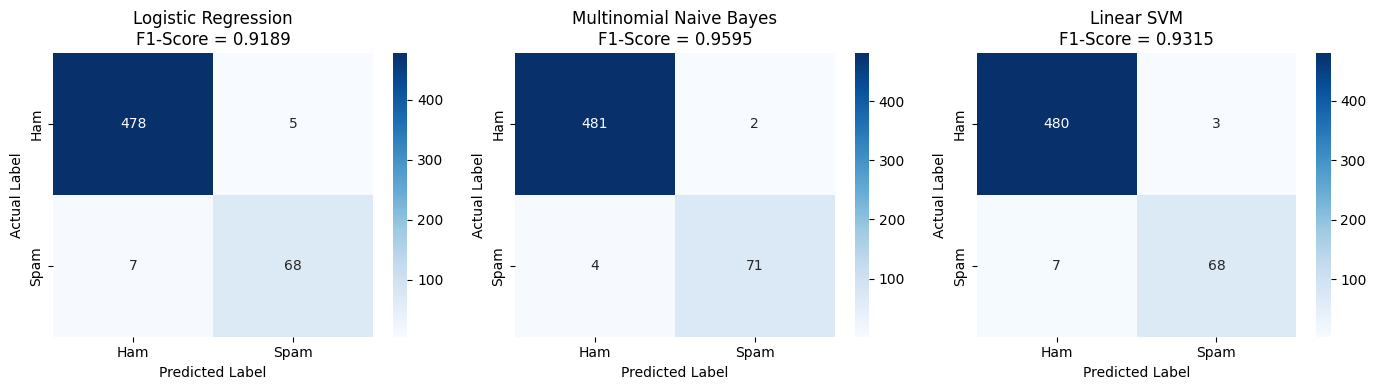

In [26]:
# Confusion Matrices for All Tuned Models on Test Dataset

import matplotlib.pyplot as plt
import seaborn as sns

model_registry = ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM']
test_prediction_list = [
    test_lr_predictions,
    test_nb_predictions,
    test_svm_predictions
]

fig, axis_array = plt.subplots(1, 3, figsize=(14, 4))

for axis, model_name, predicted_labels in zip(axis_array, model_registry, test_prediction_list):
    
    confusion_mat = confusion_matrix(y_test_target, predicted_labels)
    
    sns.heatmap(
        confusion_mat,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axis,
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )
    
    axis.set_title(
        f"{model_name}\nF1-Score = {f1_score(y_test_target, predicted_labels):.4f}"
    )
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()


AUPRC and AUROC on Test Dataset:
Logistic Regression       AUPRC: 0.9774  AUROC: 0.9932
Multinomial Naive Bayes   AUPRC: 0.9903  AUROC: 0.9968
Linear SVM                AUPRC: 0.9761  AUROC: 0.9920


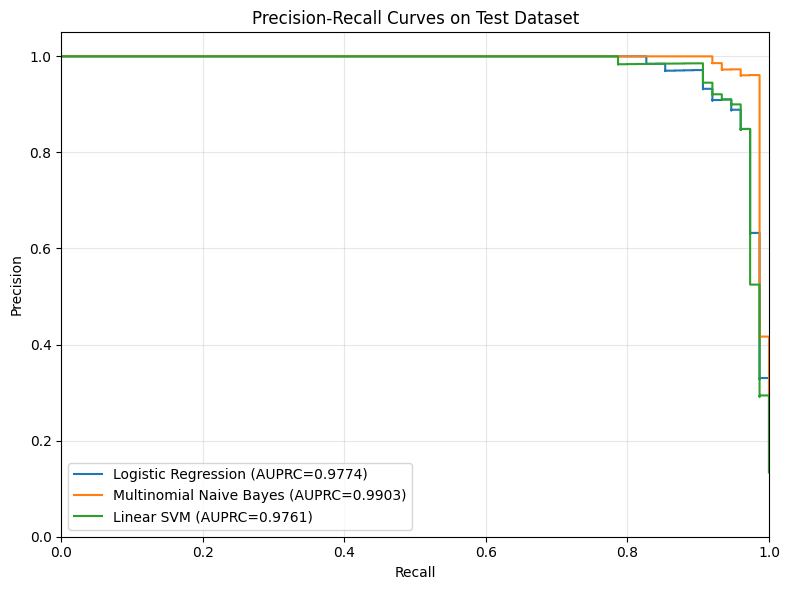

In [27]:
# AUPRC (Area Under Precision-Recall Curve) - preferred metric for imbalanced datasets

from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

# Generate probability / decision scores on test dataset
test_lr_probabilities = logistic_best_model.predict_proba(X_test_features)[:, 1]
test_nb_probabilities = naive_bayes_best_model.predict_proba(X_test_features)[:, 1]
test_svm_decision_scores = svm_best_model.decision_function(X_test_features)

test_score_list = [
    test_lr_probabilities,
    test_nb_probabilities,
    test_svm_decision_scores
]

print("AUPRC and AUROC on Test Dataset:")

for model_name, score_values in zip(model_registry, test_score_list):
    auprc_value = average_precision_score(y_test_target, score_values)
    auroc_value = roc_auc_score(y_test_target, score_values)
    
    print(f"{model_name:25} "
          f"AUPRC: {auprc_value:.4f}  "
          f"AUROC: {auroc_value:.4f}")

# Plot Precision-Recall Curves
fig, pr_axis = plt.subplots(figsize=(8, 6))

for model_name, score_values in zip(model_registry, test_score_list):
    
    precision_values, recall_values, _ = precision_recall_curve(
        y_test_target,
        score_values
    )
    
    auprc_value = average_precision_score(y_test_target, score_values)
    
    pr_axis.step(
        recall_values,
        precision_values,
        where='post',
        label=f"{model_name} (AUPRC={auprc_value:.4f})"
    )

pr_axis.set_xlabel("Recall")
pr_axis.set_ylabel("Precision")
pr_axis.set_title("Precision-Recall Curves on Test Dataset")
pr_axis.legend(loc="lower left")
pr_axis.grid(True, alpha=0.3)
pr_axis.set_xlim([0, 1])
pr_axis.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()
